In [ ]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv('Social_Network_Ads.csv')

print("First 5 rows:")
display(df.head())



First 5 rows:


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
# ==============================
# 3. Basic Info
# ==============================
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None
            User ID         Age  EstimatedSalary   Purchased
count  4.000000e+02  400.000000       400.000000  400.000000
mean   1.569154e+07   37.655000     69742.500000    0.357500
std    7.165832e+04   10.482877     34096.960282    0.479864
min    1.556669e+07   18.000000     15000.000000    0.000000
25%    1.562676e+07   29.750000     43000.000000    0.000000
50%    1.569434e+07   37.000000     70000.000000    0.000000
75%    1.575036e+07   46.000000     88000.000000    1.000000
max    1.581524e+07   60.000000    15

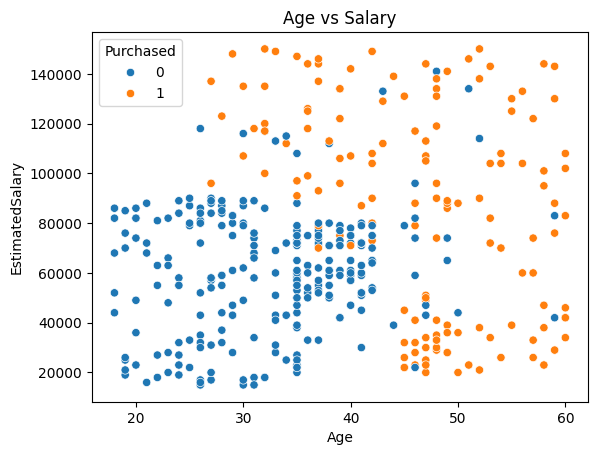

In [ ]:
# ==============================
# 4. Visualization: Age vs Salary
plt.figure()
sns.scatterplot(x='Age', y='EstimatedSalary', hue='Purchased', data=df)
plt.title("Age vs Salary")
plt.show()

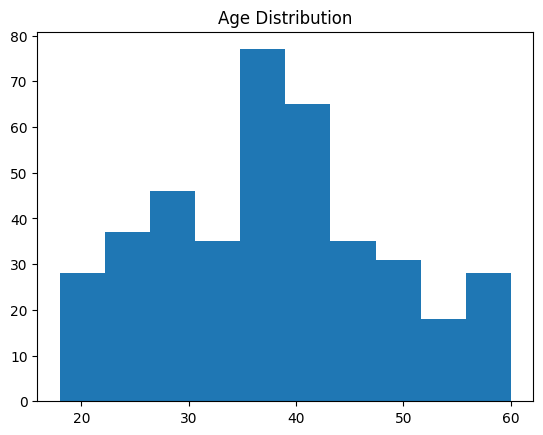

In [ ]:
# Histogram
plt.figure()
plt.hist(df['Age'])
plt.title("Age Distribution")
plt.show()

In [ ]:

# ==============================
# 5. Preprocessing
# ==============================
df = df.drop(columns=['User ID'])

df = pd.get_dummies(df, columns=['Gender'], drop_first=True)

X = df.drop(columns=['Purchased'])
y = df['Purchased']

# ==============================
# 6. Train Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 7. Scaling
# ==============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:

# ==============================
# 8. Logistic Regression
# ==============================
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# ==============================
# 9. Confusion Matrix
# ==============================
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

TN, FP, FN, TP = cm.ravel()

print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)


Confusion Matrix:
[[50  2]
 [ 7 21]]
TP: 21
TN: 50
FP: 2
FN: 7


In [ ]:

# ==============================
# 10. Metrics
# ==============================
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print("\nAccuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)



Accuracy: 0.8875
Error Rate: 0.11250000000000004
Precision: 0.9130434782608695
Recall: 0.75


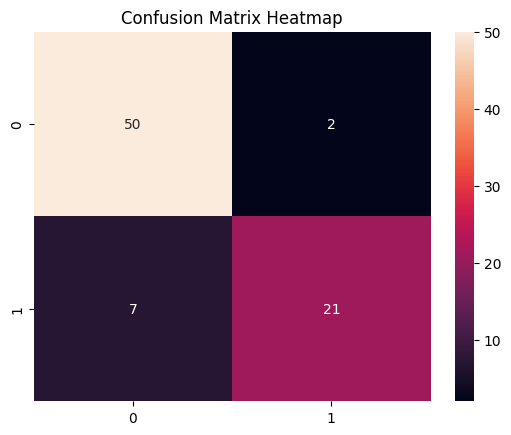

In [ ]:
# ==============================
# 11. Heatmap
# ==============================
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix Heatmap")
plt.show()

In [ ]:
# ==============================
# 12. Classification Report
# ==============================
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92        52
           1       0.91      0.75      0.82        28

    accuracy                           0.89        80
   macro avg       0.90      0.86      0.87        80
weighted avg       0.89      0.89      0.88        80

